In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
from tensorflow.keras import Sequential
from tensorflow import keras 
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121, ResNet101V2, DenseNet169,DenseNet201, Xception, ResNet152V2, InceptionV3, ResNet50, EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, MaxPooling2D, BatchNormalization, Input, concatenate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.metrics import Mean, BinaryCrossentropy, Precision, Recall
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.preprocessing import LabelEncoder
import pickle
from tqdm import tqdm
import os
os.getcwd()

from sklearn.model_selection import GridSearchCV
from keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.optimizers import Adam

In [2]:
csv_file = "Mackerel_data.csv"
data = pd.read_csv(csv_file)

In [3]:
import cv2
import tensorflow as tf
import numpy as np

def process_image(image):
    resized_image = cv2.resize(image, (224,224))
    processed_image = resized_image / 255.0
    return tf.convert_to_tensor(processed_image, dtype=tf.float32)

def resize_image(image, size):
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)
    resized_image = cv2.resize(image, (new_w, new_h))
    padded_image = pad_image(resized_image, size)
    return padded_image[:size[1], :size[0]]

def pad_image(image, size):
    h, w = image.shape[:2]
    pad_h = (size[1] - h) // 2
    pad_w = (size[0] - w) // 2
    padded_image = cv2.copyMakeBorder(
        image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    return padded_image

def load_image(image_path):
    image = cv2.imread(image_path)
    processed_image = process_image(image)
    return processed_image


# def equalize_contrast(image):
#     lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
#     lab_planes = list(cv2.split(lab_image))  # Convert tuple to list
#     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
#     lab_planes[0] = clahe.apply(lab_planes[0])
#     equalized_image = cv2.merge(lab_planes)
#     equalized_image = cv2.cvtColor(equalized_image, cv2.COLOR_LAB2BGR)
#     return equalized_image

In [4]:
classes = {'good':1,'bad':0}

In [5]:
data.head()

,image_path,label
0,.\mackerel\good\object_0_20230520104419917_mac...,good
1,.\mackerel\good\object_0_20230520104442028_mac...,good
2,.\mackerel\good\object_0_20230520104536544_mac...,good
3,.\mackerel\good\object_0_20230520105457403_mac...,good
4,.\mackerel\good\object_0_20230520105512568_mac...,good


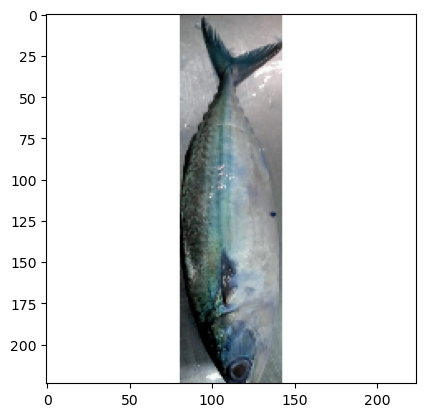

In [6]:
plt.imshow(load_image(data.image_path.iloc[0]))

In [7]:
data['label'] = data.label.replace(classes)

In [8]:
data['label'].value_counts()

1    1023
0     976
Name: label, dtype: int64

In [9]:
data = data.sample(1000)

In [10]:
from tensorflow.keras.utils import to_categorical
image_paths = data["image_path"]
freshness_labels =to_categorical(data["label"]) #to_categorical(data["label"])

In [11]:
train_image_paths, validation_image_paths,train_freshness_labels, validation_freshness_labels = train_test_split(
    image_paths,freshness_labels, test_size=0.2, stratify=freshness_labels)

In [12]:
validation_image_paths, test_image_paths,validation_freshness_labels, test_freshness_labels = train_test_split(
    validation_image_paths,validation_freshness_labels, test_size=0.25, stratify=validation_freshness_labels)

In [13]:
len(train_image_paths),len(validation_image_paths),len(test_image_paths)

(800, 150, 50)

In [14]:
len(train_freshness_labels)

800

In [15]:
train_images = np.array([load_image(image_path) for image_path in tqdm(train_image_paths)])
validation_images = np.array([load_image(image_path) for image_path in tqdm(validation_image_paths)])
test_images = np.array([load_image(image_path) for image_path in tqdm(test_image_paths)])

100%|█████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 192.51it/s]


In [16]:
train_images[0].shape

(224, 224, 3)

In [17]:
checkpoint_filepath = 'best_model.h5'
checkpoint = ModelCheckpoint(
    checkpoint_filepath,
    monitor='val_f1_score_metric',  # Monitor the validation F1 score metric
    mode='max',  # Choose the maximum value as the best
    save_best_only=True,  # Save only the best model
    save_weights_only=False,  # Save the entire model (including architecture and optimizer state)
    verbose=1
)
reduce_lr = ReduceLROnPlateau(factor=0.8, patience=20)

In [18]:
# from sklearn.metrics import f1_score

# class F1ScoreModelCheckpoint(tf.keras.callbacks.Callback):
#     def __init__(self, filepath, monitor='val_f1_score', mode='max', save_best_only=True):
#         super(F1ScoreModelCheckpoint, self).__init__()
#         self.filepath = filepath
#         self.monitor = monitor
#         self.mode = mode
#         self.save_best_only = save_best_only
#         self.best_score = -float('inf')

#     def on_epoch_end(self, epoch, logs=None):
#         val_pred = self.model.predict(self.validation_data[0])
#         val_true = tf.argmax(self.validation_data[1], axis=1)
#         val_pred = tf.argmax(val_pred, axis=1)

#         val_f1_score = f1_score(val_true, val_pred)

#         if self.mode == 'max':
#             if val_f1_score > self.best_score:
#                 self.best_score = val_f1_score
#                 self.model.save(self.filepath)
#                 print(f"Epoch {epoch + 1} - Best {self.monitor}: {self.best_score:.4f}")
#         else:
#             if val_f1_score < self.best_score:
#                 self.best_score = val_f1_score
#                 self.model.save(self.filepath)
#                 print(f"Epoch {epoch + 1} - Best {self.monitor}: {self.best_score:.4f}")


# checkpoint = F1ScoreModelCheckpoint(filepath='best_model.h5')



In [19]:
# model = Sequential()
# base = DenseNet201(weights='imagenet', include_top=False, input_shape=(224,224,3))
# base.trainable=False
# model.add(base)
# model.add(GlobalAveragePooling2D())
# model.add(Dense(4096, activation='relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.7))
# model.add(Dense(1024, activation='relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.7))
# model.add(Dense(2, activation='softmax'))

# learning_rate = 0.0001
# optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
# model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# # MODEL SUMMARY
# model.summary()

In [20]:
input_shape = (224, 224, 3)
num_classes = 2
input_tensor = Input(shape=input_shape)
densenet121 = DenseNet121(include_top=False, weights='imagenet', input_tensor=input_tensor)
densenet169 = DenseNet169(include_top=False, weights='imagenet', input_tensor=input_tensor)
densenet201 = DenseNet201(include_top=False, weights='imagenet', input_tensor=input_tensor)

for layer in densenet121.layers:
    layer.trainable = False
    layer._name = layer.name + "_121"
for layer in densenet169.layers:
    layer.trainable = False
    layer._name = layer.name + "169"
for layer in densenet201.layers:
    layer.trainable = False
    layer._name = layer.name + "201"

gap_densenet121 = GlobalAveragePooling2D(name='gap_densenet121')(densenet121.output)
dropout_densenet121 = Dropout(0.7)(gap_densenet121)
dense_densenet121 = Dense(units=128, activation='relu')(dropout_densenet121)

gap_densenet169 = GlobalAveragePooling2D(name='gap_densenet169')(densenet169.output)
dropout_densenet169 = Dropout(0.7)(gap_densenet169)
dense_densenet169 = Dense(units=128, activation='relu')(dropout_densenet169)

gap_densenet201 = GlobalAveragePooling2D(name='gap_densenet201')(densenet201.output)
dropout_densenet201 = Dropout(0.7)(gap_densenet201)
dense_densenet201 = Dense(units=128, activation='relu')(dropout_densenet201)


merged_features = concatenate([dense_densenet121, dense_densenet169, dense_densenet201])
dense_layer = Dense(units=64, activation='relu')(merged_features)
smoothing_factor = 0.2
output = Dense(units=num_classes, activation='softmax',
               kernel_regularizer=tf.keras.regularizers.l2(0.5))(dense_layer)
output = tf.keras.layers.Lambda(lambda x: (1 - smoothing_factor) * x + smoothing_factor / num_classes)(output)

model = Model(inputs=input_tensor, outputs=output)

# Compile the model
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=5)
learning_rate = 0.0001
optimizer = Adam(learning_rate=learning_rate)
loss_function = CategoricalCrossentropy(label_smoothing=smoothing_factor)

model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])

# # Print the model summary
# # model.summary()

In [21]:
# branch1 = Sequential()
# branch1.add(Dense(2048, activation='relu'))
# branch1.add(BatchNormalization())
# branch1.add(Dense(1024, activation='relu'))
# branch1.add(BatchNormalization())
# branch1.add(Dense(1, activation='sigmoid'))

# branch2 = Sequential()
# branch2.add(Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.9)))
# branch2.add(BatchNormalization())
# branch2.add(Dense(256, activation='relu'))
# branch2.add(BatchNormalization())
# branch2.add(Dense(1, activation='sigmoid'))

# branch3 = Sequential()
# branch3.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.9)))
# branch3.add(BatchNormalization())
# branch3.add(Dense(512, activation='relu'))
# branch3.add(BatchNormalization())
# branch3.add(Dense(1, activation='sigmoid'))

# branch4 = Sequential()
# branch4.add(Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.9)))
# branch4.add(BatchNormalization())
# branch4.add(Dense(2048, activation='relu'))
# branch4.add(BatchNormalization())
# branch4.add(Dense(1, activation='sigmoid'))

# model = Sequential()
# base = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# base.trainable = False
# model.add(base)
# model.add(GlobalAveragePooling2D())

# output1 = branch1(model.output)
# output2 = branch2(model.output)
# output3 = branch3(model.output)
# output4 = branch4(model.output)

# combined_output = Concatenate()([output1, output2,output3,output4])

# # Create the final model
# final_output = Dense(2, activation='softmax')(combined_output)

# model = Model(inputs=model.input, outputs=final_output)

# learning_rate = 0.0001
# optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
# model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# # MODEL SUMMARY
# model.summary()

In [22]:
# image_size = (224, 224)  # Input image dimensions
# num_classes = 2  # Number of classes
# base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
# base_model.trainable=False
# model = Sequential()
# model.add(base_model)
# model.add(GlobalAveragePooling2D())
# model.add(Dense(256, activation='relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.5))
# smoothing_factor = 0.1
# model.add(Dense(units=num_classes, activation='softmax',kernel_regularizer=tf.keras.regularizers.l2(0.01)))
# # model.add(tf.keras.layers.Lambda(lambda x: (1 - smoothing_factor) * x + smoothing_factor / num_classes))

# # Compile the model
# reduce_lr = ReduceLROnPlateau(factor=0.5, patience=5)
# learning_rate = 0.0001
# optimizer = Adam(learning_rate=learning_rate)
# loss_function = CategoricalCrossentropy(label_smoothing=smoothing_factor)

# model.compile(optimizer=optimizer, loss=loss_function, metrics=['accuracy'])
# model.summary()

In [23]:
# units_per_dense_block = [64, 16, 128, 512, 512, 16, 128]
# dropout_rate = 0.5
# optimizer_choice = 'adam'
# learning_rate = 0.001
# base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# base_model.trainable=False
# x = GlobalAveragePooling2D()(base_model.output)
# for units in units_per_dense_block:
#     x = Dense(units, activation='relu')(x)
#     x = Dropout(0.25)(x)
# x = Dropout(dropout_rate)(x)
# outputs = Dense(2, activation='softmax')(x)
# model = Model(inputs=base_model.input, outputs=outputs)
# if optimizer_choice == 'adam':
#     optimizer = Adam(learning_rate=learning_rate)
# elif optimizer_choice == 'sgd':
#     optimizer = SGD(learning_rate=learning_rate)
# else:
#     raise ValueError('Invalid optimizer choice.')
# model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=[tf.keras.metrics.AUC()])

# # Print the model summary
# model.summary()

In [24]:
train_images = train_images.astype(np.float32)
train_freshness_labels = train_freshness_labels.astype(np.float32)
validation_images = validation_images.astype(np.float32)
validation_freshness_labels = validation_freshness_labels.astype(np.float32)

In [25]:
# train_freshness_labels = train_freshness_labels.astype(np.int64)
# validation_freshness_labels = validation_freshness_labels.astype(np.int64)

In [26]:
def f1_score_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(tf.math.round(y_pred), tf.float32)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum(y_pred) - tp
    fn = tf.reduce_sum(y_true) - tp
    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())
    f1_score = 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())
    return f1_score

In [27]:
# smoothing_factor = 0.2
# model = tf.keras.models.load_model('best_model.h5',custom_objects={'f1_score_metric': f1_score_metric})

In [28]:
# f1_score_metric = tf.keras.metrics.get(f1_score_metric)
# model.save('best_model.h5')

In [29]:
learning_rate = 0.001
smoothing_factor = 0.2
optimizer = Adam(learning_rate=learning_rate)
loss_function = CategoricalCrossentropy(label_smoothing=smoothing_factor)
# early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_f1_score_metric', patience=10, mode='max')
model.compile(optimizer=optimizer, loss=loss_function, metrics=[tf.keras.metrics.get(f1_score_metric)])

# model.summary()

with tf.device('/GPU:0'):
    history = model.fit(
        train_images,
        train_freshness_labels,
        validation_data=(validation_images,validation_freshness_labels),
        epochs=200,
        callbacks=[checkpoint]
)


Epoch 1/200
25/25 [==============================] - ETA: 0s - loss: 2.4902 - f1_score_metric: 0.5475
Epoch 1: val_f1_score_metric improved from -inf to 0.51023, saving model to best_model.h5
25/25 [==============================] - 61s 1s/step - loss: 2.4902 - f1_score_metric: 0.5475 - val_loss: 2.2387 - val_f1_score_metric: 0.5102
Epoch 2/200
25/25 [==============================] - ETA: 0s - loss: 2.0565 - f1_score_metric: 0.5562
Epoch 2: val_f1_score_metric improved from 0.51023 to 0.60852, saving model to best_model.h5
25/25 [==============================] - 20s 803ms/step - loss: 2.0565 - f1_score_metric: 0.5562 - val_loss: 1.8548 - val_f1_score_metric: 0.6085
Epoch 3/200
25/25 [==============================] - ETA: 0s - loss: 1.7283 - f1_score_metric: 0.6062
Epoch 3: val_f1_score_metric improved from 0.60852 to 0.64375, saving model to best_model.h5
25/25 [==============================] - 23s 942ms/step - loss: 1.7283 - f1_score_metric: 0.6062 - val_loss: 1.5768 - val_f1_scor

Epoch 27/200
25/25 [==============================] - ETA: 0s - loss: 0.6181 - f1_score_metric: 0.7175
Epoch 27: val_f1_score_metric did not improve from 0.75170
25/25 [==============================] - 15s 618ms/step - loss: 0.6181 - f1_score_metric: 0.7175 - val_loss: 0.6078 - val_f1_score_metric: 0.7148
Epoch 28/200
25/25 [==============================] - ETA: 0s - loss: 0.6098 - f1_score_metric: 0.7212
Epoch 28: val_f1_score_metric did not improve from 0.75170
25/25 [==============================] - 15s 620ms/step - loss: 0.6098 - f1_score_metric: 0.7212 - val_loss: 0.6083 - val_f1_score_metric: 0.7091
Epoch 29/200
25/25 [==============================] - ETA: 0s - loss: 0.5994 - f1_score_metric: 0.7375
Epoch 29: val_f1_score_metric did not improve from 0.75170
25/25 [==============================] - 15s 618ms/step - loss: 0.5994 - f1_score_metric: 0.7375 - val_loss: 0.6021 - val_f1_score_metric: 0.7307
Epoch 30/200
25/25 [==============================] - ETA: 0s - loss: 0.6147

25/25 [==============================] - 15s 620ms/step - loss: 0.5997 - f1_score_metric: 0.7387 - val_loss: 0.6247 - val_f1_score_metric: 0.6875
Epoch 54/200
25/25 [==============================] - ETA: 0s - loss: 0.6011 - f1_score_metric: 0.7362
Epoch 54: val_f1_score_metric did not improve from 0.76136
25/25 [==============================] - 15s 619ms/step - loss: 0.6011 - f1_score_metric: 0.7362 - val_loss: 0.5980 - val_f1_score_metric: 0.7182
Epoch 55/200
25/25 [==============================] - ETA: 0s - loss: 0.5992 - f1_score_metric: 0.7425
Epoch 55: val_f1_score_metric did not improve from 0.76136
25/25 [==============================] - 15s 620ms/step - loss: 0.5992 - f1_score_metric: 0.7425 - val_loss: 0.6301 - val_f1_score_metric: 0.6875
Epoch 56/200
25/25 [==============================] - ETA: 0s - loss: 0.5760 - f1_score_metric: 0.7725
Epoch 56: val_f1_score_metric did not improve from 0.76136
25/25 [==============================] - 15s 619ms/step - loss: 0.5760 - f1_

25/25 [==============================] - ETA: 0s - loss: 0.5934 - f1_score_metric: 0.7450
Epoch 80: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 619ms/step - loss: 0.5934 - f1_score_metric: 0.7450 - val_loss: 0.5970 - val_f1_score_metric: 0.7210
Epoch 81/200
25/25 [==============================] - ETA: 0s - loss: 0.5749 - f1_score_metric: 0.7575
Epoch 81: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 620ms/step - loss: 0.5749 - f1_score_metric: 0.7575 - val_loss: 0.5991 - val_f1_score_metric: 0.7182
Epoch 82/200
25/25 [==============================] - ETA: 0s - loss: 0.5744 - f1_score_metric: 0.7637
Epoch 82: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 619ms/step - loss: 0.5744 - f1_score_metric: 0.7637 - val_loss: 0.6050 - val_f1_score_metric: 0.7028
Epoch 83/200
25/25 [==============================] - ETA: 0s - loss: 0.5625 - f1_score_m

Epoch 107/200
25/25 [==============================] - ETA: 0s - loss: 0.5601 - f1_score_metric: 0.7762
Epoch 107: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 616ms/step - loss: 0.5601 - f1_score_metric: 0.7762 - val_loss: 0.6251 - val_f1_score_metric: 0.6994
Epoch 108/200
25/25 [==============================] - ETA: 0s - loss: 0.5534 - f1_score_metric: 0.7837
Epoch 108: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 617ms/step - loss: 0.5534 - f1_score_metric: 0.7837 - val_loss: 0.6171 - val_f1_score_metric: 0.7057
Epoch 109/200
25/25 [==============================] - ETA: 0s - loss: 0.5581 - f1_score_metric: 0.7887
Epoch 109: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 617ms/step - loss: 0.5581 - f1_score_metric: 0.7887 - val_loss: 0.5968 - val_f1_score_metric: 0.7301
Epoch 110/200
25/25 [==============================] - ETA: 0s - loss:

25/25 [==============================] - 15s 621ms/step - loss: 0.5358 - f1_score_metric: 0.8087 - val_loss: 0.5995 - val_f1_score_metric: 0.7483
Epoch 134/200
25/25 [==============================] - ETA: 0s - loss: 0.5333 - f1_score_metric: 0.8175
Epoch 134: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 620ms/step - loss: 0.5333 - f1_score_metric: 0.8175 - val_loss: 0.5894 - val_f1_score_metric: 0.7699
Epoch 135/200
25/25 [==============================] - ETA: 0s - loss: 0.5285 - f1_score_metric: 0.8087
Epoch 135: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 621ms/step - loss: 0.5285 - f1_score_metric: 0.8087 - val_loss: 0.5945 - val_f1_score_metric: 0.7244
Epoch 136/200
25/25 [==============================] - ETA: 0s - loss: 0.5061 - f1_score_metric: 0.8462
Epoch 136: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 622ms/step - loss: 0.5061

Epoch 160/200
25/25 [==============================] - ETA: 0s - loss: 0.5248 - f1_score_metric: 0.8075
Epoch 160: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 623ms/step - loss: 0.5248 - f1_score_metric: 0.8075 - val_loss: 0.5886 - val_f1_score_metric: 0.7398
Epoch 161/200
25/25 [==============================] - ETA: 0s - loss: 0.5157 - f1_score_metric: 0.8300
Epoch 161: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 16s 625ms/step - loss: 0.5157 - f1_score_metric: 0.8300 - val_loss: 0.5921 - val_f1_score_metric: 0.7455
Epoch 162/200
25/25 [==============================] - ETA: 0s - loss: 0.5117 - f1_score_metric: 0.8350
Epoch 162: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 623ms/step - loss: 0.5117 - f1_score_metric: 0.8350 - val_loss: 0.6073 - val_f1_score_metric: 0.7335
Epoch 163/200
25/25 [==============================] - ETA: 0s - loss:

25/25 [==============================] - 15s 620ms/step - loss: 0.4892 - f1_score_metric: 0.8600 - val_loss: 0.5924 - val_f1_score_metric: 0.7580
Epoch 187/200
25/25 [==============================] - ETA: 0s - loss: 0.4980 - f1_score_metric: 0.8450
Epoch 187: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 620ms/step - loss: 0.4980 - f1_score_metric: 0.8450 - val_loss: 0.6104 - val_f1_score_metric: 0.7239
Epoch 188/200
25/25 [==============================] - ETA: 0s - loss: 0.4911 - f1_score_metric: 0.8575
Epoch 188: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 622ms/step - loss: 0.4911 - f1_score_metric: 0.8575 - val_loss: 0.6277 - val_f1_score_metric: 0.7182
Epoch 189/200
25/25 [==============================] - ETA: 0s - loss: 0.5023 - f1_score_metric: 0.8562
Epoch 189: val_f1_score_metric did not improve from 0.77955
25/25 [==============================] - 15s 621ms/step - loss: 0.5023

In [30]:
model.save('best_model.h5')

In [31]:
model = tf.keras.models.load_model('best_model.h5',custom_objects={'f1_score_metric': f1_score_metric})

Max Freshness train accuracy: 0.8812499046325684
Max Freshness Validation accuracy: 0.7795454263687134
Min Freshness train loss: 0.4724918007850647
Min Freshness Validation loss: 0.5803734064102173


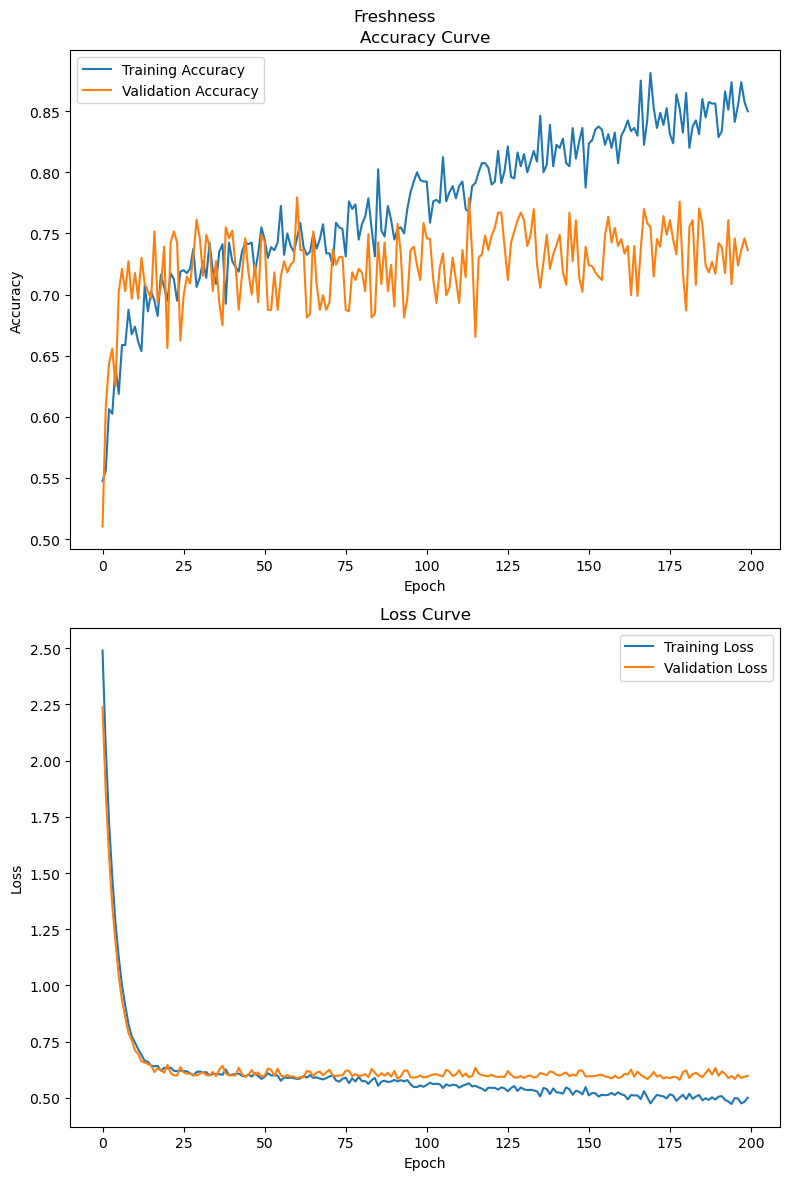

In [32]:
accuracy = history.history['f1_score_metric']
val_accuracy = history.history['val_f1_score_metric']
loss = history.history['loss']
val_loss = history.history['val_loss']

print('Max Freshness train accuracy:', np.max(accuracy))
print('Max Freshness Validation accuracy:', np.max(val_accuracy))
print('Min Freshness train loss:', np.min(loss))
print('Min Freshness Validation loss:', np.min(val_loss))

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 12))
#accuracy
axes[0].plot(accuracy, label='Training Accuracy')
axes[0].plot(val_accuracy, label='Validation Accuracy')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

#loss
axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Freshness')
plt.tight_layout()
plt.savefig('Mackerel_training.png')
plt.show()

In [33]:
res=model.predict(test_images)

2/2 [==============================] - 14s 4s/step


In [34]:
results = [np.argmax(x) for x in res]

In [35]:
predicted_label=results

In [36]:
def generate_classification_report(true_labels, predicted_labels, labels):
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='macro')
    recall = recall_score(true_labels, predicted_labels, average='macro')
    f1 = f1_score(true_labels, predicted_labels, average='macro')
    
    classification_rep = classification_report(true_labels, predicted_labels)
    confusion_mat = confusion_matrix(true_labels, predicted_labels)
    
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("\nClassification Report:")
    print(classification_rep)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.xticks(ticks=range(len(labels)), labels=labels)
    plt.yticks(ticks=range(len(labels)), labels=labels)
    name = 'Fresh'
    plt.savefig(name+'Mackerel_Confusion_matrix_today.png')
    plt.show()

Accuracy: 0.82
Precision: 0.8205128205128205
Recall: 0.8200000000000001
F1-score: 0.8199279711884755

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        25
           1       0.83      0.80      0.82        25

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.82      0.82      0.82        50



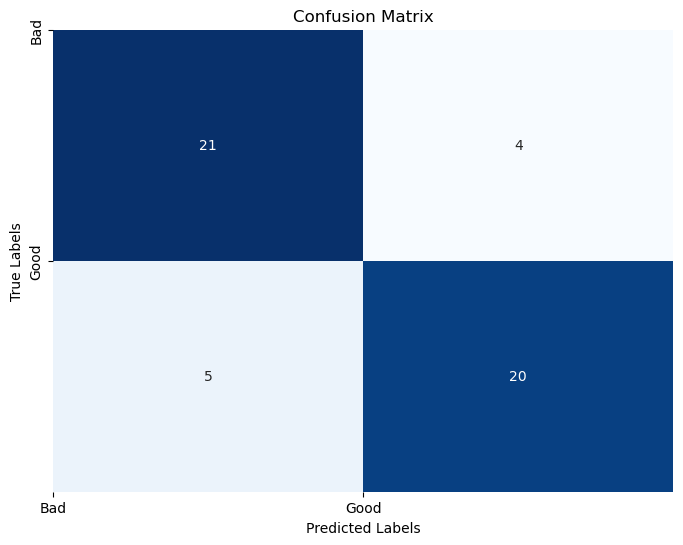

In [37]:
generate_classification_report([np.argmax(x) for x in test_freshness_labels],predicted_label,['Bad','Good'])